100%|██████████| 2.26G/2.26G [03:42<00:00, 10.9MB/s]


Loaded an audio clip for the word: 'backward'


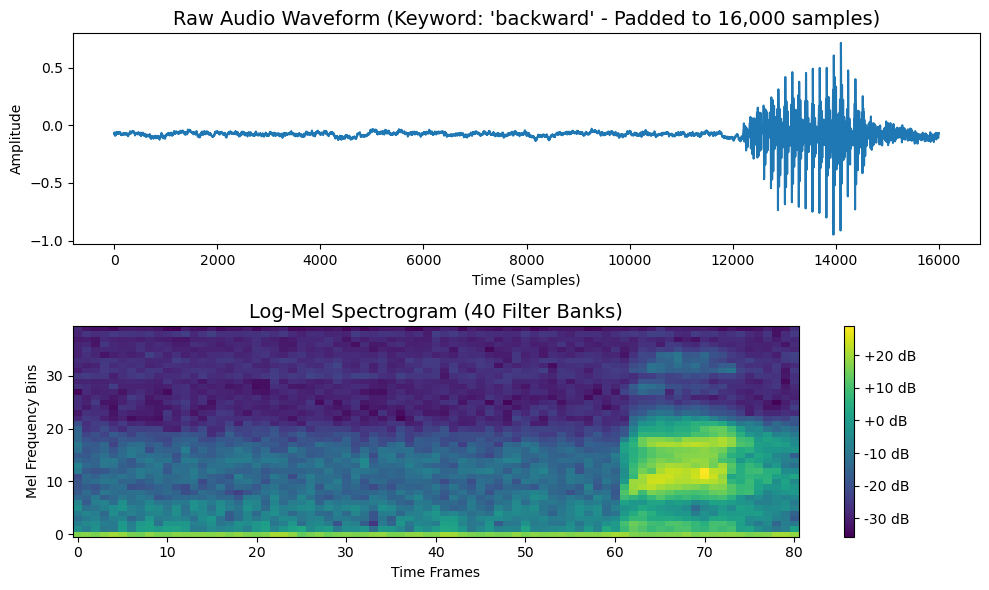

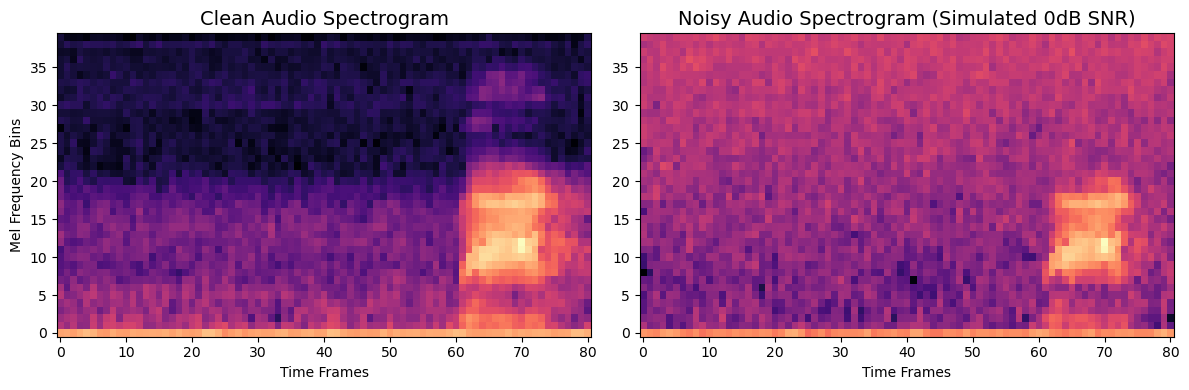

In [1]:
import torch
import torchaudio
import matplotlib.pyplot as plt
import torchaudio.transforms as T
import torch.nn.functional as F
from torchaudio.datasets import SPEECHCOMMANDS
import os

os.makedirs("./dataset", exist_ok=True)

# finds the cached data OR downloads.
dataset = SPEECHCOMMANDS("./dataset", download=True)

# audio clip from the dataset
waveform, sample_rate, label, speaker_id, utterance_number = dataset[0]
print(f"Loaded an audio clip for the word: '{label}'")

# MATCHING DATA_LOADING.IPYNB
if waveform.shape[1] < 16000:
    padding = 16000 - waveform.shape[1]
    waveform = F.pad(waveform, (0, padding))
elif waveform.shape[1] > 16000:
    waveform = waveform[:, :16000]

# Graphic One: Waveform vs. Spectrogram 
spectrogram_transform = T.MelSpectrogram(sample_rate=sample_rate, n_mels=40)
mel_spec = spectrogram_transform(waveform)
log_mel_spec = torchaudio.transforms.AmplitudeToDB()(mel_spec)

fig, axs = plt.subplots(2, 1, figsize=(10, 6))

# Plot Waveform
axs[0].plot(waveform.t().numpy(), color='#1f77b4')
axs[0].set_title(f"Raw Audio Waveform (Keyword: '{label}' - Padded to 16,000 samples)", fontsize=14)
axs[0].set_ylabel("Amplitude")
axs[0].set_xlabel("Time (Samples)")

# Plot Spectrogram
im = axs[1].imshow(log_mel_spec[0].numpy(), aspect='auto', origin='lower', cmap='viridis')
axs[1].set_title("Log-Mel Spectrogram (40 Filter Banks)", fontsize=14)
axs[1].set_ylabel("Mel Frequency Bins")
axs[1].set_xlabel("Time Frames")
fig.colorbar(im, ax=axs[1], format="%+2.0f dB")

plt.tight_layout()
plt.savefig("waveform_vs_spectrogram.png", dpi=300) 
plt.show()

# Graphic Two: Clean vs. Noisy Spectrogram 
noise = torch.randn_like(waveform) * 0.05 
noisy_waveform = waveform + noise
noisy_mel_spec = torchaudio.transforms.AmplitudeToDB()(spectrogram_transform(noisy_waveform))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Plot 
axs[0].imshow(log_mel_spec[0].numpy(), aspect='auto', origin='lower', cmap='magma')
axs[0].set_title("Clean Audio Spectrogram", fontsize=14)
axs[0].set_ylabel("Mel Frequency Bins")
axs[0].set_xlabel("Time Frames")

# Plot Noisy
axs[1].imshow(noisy_mel_spec[0].numpy(), aspect='auto', origin='lower', cmap='magma')
axs[1].set_title("Noisy Audio Spectrogram (Simulated 0dB SNR)", fontsize=14)
axs[1].set_xlabel("Time Frames")

plt.tight_layout()
plt.savefig("clean_vs_noisy.png", dpi=300) 
plt.show()